# A layered cache stack for an AI agent

A production agent rarely uses one cache. It stacks several, each in front of a different kind of
work: a stored answer for an identical question, a stored answer for a question that *means* the
same thing, a stored vector for text it has already embedded, a provider-side cache for the long
prompt prefix it sends on every call, and a short-lived store of tool results. Each layer skips a
different cost, and each can be wrong in its own way.

The use case is a **developer-support agent for the Django codebase**. Engineers ask it why a known
bug happens (answered from a knowledge base of real, resolved Django issues stored in Oracle AI
Database) and what changed in the latest release (answered from a live web search). You will add the
five cache layers **one at a time** and run **the same six requests** under every configuration, so
each layer's effect is measured rather than assumed.

**What you will build and measure**

- A knowledge base of 114 resolved Django issues in `OracleVS` with an HNSW index, plus reranked retrieval.
- Layer 1 · an **exact answer cache** on **Oracle True Cache**: writes go to the primary database, reads are
  served by True Cache, with a fallback to the primary.
- Layer 2 · an **embedding cache** for the local open-source encoder, behind a LangChain `Embeddings` adapter.
- Layer 3 · a **semantic answer cache** with `OracleSemanticCache`, plus a reranker check of every match.
- Layer 4 · **Anthropic prompt caching** on the stable part of the prompt.
- Layer 5 · a short-lived **tool-result cache** for Tavily web search.
- A results table and chart with latency, model calls, encoder runs, tool calls and estimated cost per
  configuration, with savings measured against the uncached baseline.

**What you need:** an Anthropic API key, a Tavily API key, a dedicated schema in Oracle AI Database 23ai or
later with a vector memory pool (for the knowledge base and semantic cache), and an Oracle True Cache pair (a
primary database plus a True Cache instance; the folder's README shows how to run both with Docker).
Internet access is needed the first time, to download the two small models and the dataset. A full run
makes about 28 Claude calls and 4 Tavily searches and takes a few minutes.

### Install the notebook packages

Use a **Python 3.12** kernel. Open this notebook from the `cache_techniques` folder so `requirements.txt` is available. Run the next cell before Part 1: **%pip** installs into the Python environment used by this notebook's active kernel.

`requirements.txt` installs **anthropic** for Claude, **sentence-transformers** for the open-source Hugging Face embedding model and reranker (it brings PyTorch and transformers), **oracledb** and **langchain-oracledb** for Oracle AI Database, **tavily-python** for web search, **pandas**, **pyarrow** and **huggingface_hub** for reading public Hugging Face datasets, and **numpy** and **matplotlib** for measurements and charts. It also installs JupyterLab, plus nbformat and nbclient, which `tests/run_notebooks.py` uses to run a notebook end to end.

After the first installation finishes, **restart the kernel**, then run the Parts in order. Installation needs internet access; it does not need your API keys.

In [1]:
# Install packages into this notebook's active Python kernel.
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Part 1 · How a layered cache stack works

## 1.1 · The idea

Every request an agent answers costs several kinds of work. A layered stack puts one cache in front of
each kind, ordered so that the cheapest check that could answer the whole request runs first:

| Layer | What it stores | What a hit skips | Where it lives here |
|---|---|---|---|
| 1 · Exact answer | the final answer for an identical question | everything: retrieval, model call, tools | Oracle table on the True Cache primary, read through True Cache |
| 2 · Embedding | the vector for an exact text | one run of the encoder | a dictionary in the agent process |
| 3 · Semantic answer | answers indexed by the meaning of their question | retrieval and the model call | `OracleSemanticCache` table with an HNSW index |
| 4 · Prompt prefix | the provider's processed state of the stable prompt prefix | re-processing those input tokens (most of their price) | Anthropic's servers |
| 5 · Tool result | the result of a read-only tool call | a provider round trip and its metered credit | a dictionary with a short TTL |

Two of these layers (1 and 3) **replace the answer**: on a hit the model is not called at all. The
other three **make a fresh answer cheaper**: the model still reasons over current evidence, but less
work is repeated on the way. That distinction drives the most important rule of the stack, which
requests may reuse an answer at all.

## 1.2 · The request flow

The diagram follows one request through the stack. The host application, not the model, labels each
request before it enters: an **explanation** about the codebase may reuse a stored answer; a **live**
request about current facts may not.

**Figure · One request through the five cache layers**

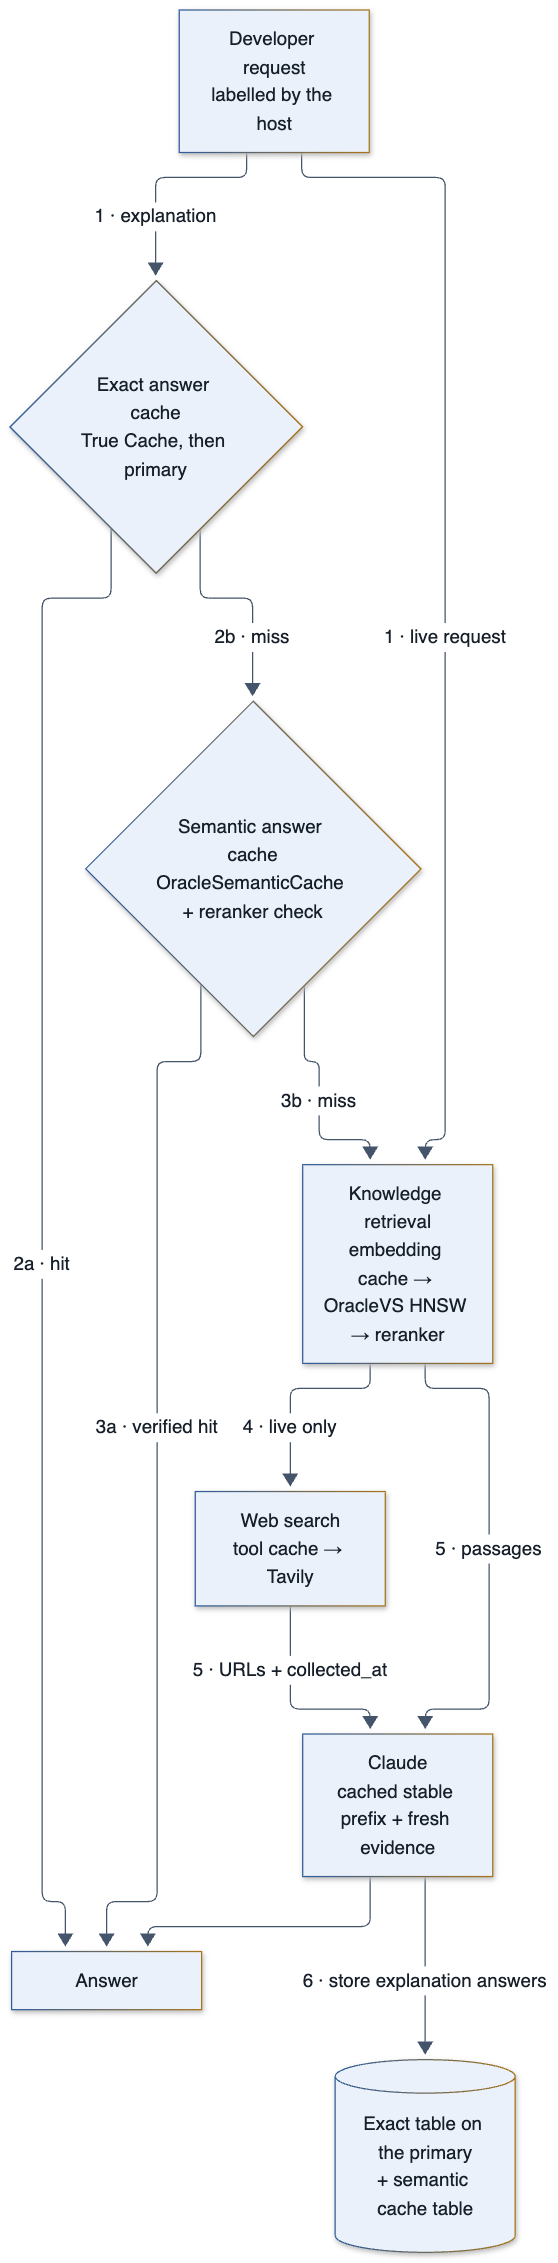

<details><summary>Mermaid source</summary>

```mermaid
flowchart TB
    Q["Developer request<br/>labelled by the host"] -->|1 · explanation| X{"Exact answer cache<br/>True Cache, then primary"}
    Q -->|1 · live request| Ret
    X -->|2a · hit| Ans["Answer"]
    X -->|2b · miss| Sem{"Semantic answer cache<br/>OracleSemanticCache + reranker check"}
    Sem -->|3a · verified hit| Ans
    Sem -->|3b · miss| Ret["Knowledge retrieval<br/>embedding cache → OracleVS HNSW → reranker"]
    Ret -->|4 · live only| Tool["Web search<br/>tool cache → Tavily"]
    Ret -->|5 · passages| LLM["Claude<br/>cached stable prefix + fresh evidence"]
    Tool -->|5 · URLs + collected_at| LLM
    LLM --> Ans
    LLM -->|6 · store explanation answers| Store[("Exact table on the primary<br/>+ semantic cache table")]
```

</details>

Step by step:

1. **Label.** The host decides whether the request is an *explanation* (stable, answerable from the
   knowledge base) or *live* (depends on the current state of the web). Live requests skip steps 2–3.
2. **Exact answer cache.** The agent hashes the question with everything that shaped the answer (model,
   prompt version, namespace) and reads that key **through Oracle True Cache**. A miss there is checked
   once on the **primary**, because True Cache can trail the primary by a fraction of a second.
   - **2a.** A hit returns the stored answer immediately.
3. **Semantic answer cache.** The question is embedded and `OracleSemanticCache` finds the nearest
   cached question within a distance threshold. A **cross-encoder reranker** then reads the new and the
   cached question *together* and must agree they ask the same thing.
   - **3a.** A verified hit returns that stored answer.
4. **Evidence.** The question is embedded (the **embedding cache** may already hold that vector),
   `OracleVS` finds candidate issues with an HNSW index, and the reranker keeps the best passages. Live
   requests also call the **web-search tool**, through the **tool cache**.
5. **Generate.** Claude receives the **stable prefix** (instructions, tool description, an index of
   known issues) followed by the fresh evidence. With **prompt caching** on, the prefix ends in a cache
   breakpoint, so Anthropic reads it from its cache instead of processing it again.
6. **Store.** New explanation answers are written to the exact table **on the primary** (True Cache
   picks them up from the redo stream) and to the semantic cache. Live answers are never stored.

## 1.3 · Why live requests bypass answer reuse

An answer cache returns *what the agent said before*. For "why does `FileBasedCache.has_key` race?"
that is fine: the explanation does not change between two questions a few minutes apart. For "what is
new in the latest Django release?" a stored answer is a claim about the world at the moment it was
written. Serving it later presents old facts as current.

So the stack treats the two kinds differently:

- **Live requests never read or write layers 1 and 3.** They always reach the model with fresh evidence.
- They can still use the layers that keep a fresh answer cheap: the **embedding cache**, the **prompt
  cache**, and a **tool cache** with a short TTL that preserves the original `collected_at` time, so the
  answer can say when its evidence was gathered.
- The label comes from the host application's routing (an endpoint, a tool choice, a rule), not from the
  model guessing whether its own answer may be reused.

## 1.4 · What each layer can get wrong

Each layer trades a cost for a specific risk. The guard for each risk is built into this notebook.

| Layer | Failure mode | Guard used here |
|---|---|---|
| Exact answer | serves an answer produced under a different prompt or model; serves it after it went stale | key includes model and a per-configuration namespace; `expires_at` checked on every read |
| Exact answer (True Cache) | a read right after a write misses because the replica has not applied the redo yet | a miss on True Cache is checked once on the primary before calling the model |
| Embedding | reuses a vector from a different model, revision or normalisation | key includes model, revision, normalisation and the exact text |
| Semantic answer | **false recall**: a similar but different question receives the wrong answer | conservative distance threshold, a reranker check, a namespace per configuration, expiry |
| Prompt prefix | silently stops hitting when anything before the breakpoint changes | stable content only before the breakpoint; usage counters show reads and writes |
| Tool result | serves stale web evidence; caches an action | short TTL, original `collected_at` kept, read-only tool only |

## 1.5 · Freshness and invalidation per layer

- **Exact answers** expire by `expires_at`, and are invalidated by changing the key (a new model or prompt
  version produces new keys). The cache *tier* needs no invalidation code: True Cache applies every insert,
  update and delete made on the primary from redo. Deleting a row on the primary removes it from True Cache.
- **Embeddings** never go stale for the same model and text; they are invalidated by the model identity in
  the key. Upgrading the model means a new key space, not an in-place update.
- **Semantic answers** expire with the TTL stored in the cached envelope, and each configuration writes to
  its own namespace. Changing the knowledge or the prompt should mean a new namespace.
- **The prompt prefix** lives in Anthropic's cache for five minutes after its last use (refreshed on every
  hit). Changing one character before the breakpoint means a new cache write.
- **Tool results** live for 120 seconds here; the agent always reports when the evidence was collected.

## 1.6 · Measuring a stack fairly

Comparing configurations is easy to get wrong. This notebook follows four rules:

- **One frozen workload.** Every configuration answers the same six requests in the same order.
- **Cold start per configuration.** Each configuration gets new application caches, a new semantic-cache
  namespace and a unique marker at the start of its prompt prefix, so no configuration benefits from an
  earlier one's warm cache.
- **Setup measured separately.** Building the stack (opening tables, probing the embedding size) is not
  counted as request latency.
- **Signed savings.** Savings are reported against the measured baseline, and a layer that adds latency or
  cost shows a negative number instead of being hidden.

### Takeaways

- Answer layers (exact, semantic) skip the model; the other layers make a fresh answer cheaper.
- Order the layers so the cheapest check that could answer the whole request runs first.
- Live requests never reuse a stored answer; they still benefit from embedding, prompt and tool caching.
- Every layer has its own failure mode and its own invalidation rule; design both explicitly.

# Part 2 · The use case: a developer-support agent for Django

## 2.1 · The scenario

A team builds on Django and runs an internal support agent in its chat tool. Two kinds of questions
dominate:

- **"Why does this happen?"** questions about known framework bugs: race conditions in a cache backend,
  migrations that are not optimised, query-builder crashes. The answers live in the agent's knowledge base:
  **114 real, resolved Django issues** from the public SWE-bench Lite dataset, stored in Oracle with vectors.
  Several engineers hit the same bug in the same week, so the same question arrives again, sometimes word
  for word and sometimes rephrased.
- **"What is current?"** questions about releases and deprecations, answered from a live web search. The
  agent's planner tends to repeat the same search within a short time (one engineer asks, a teammate asks
  again a minute later).

Every answer goes through Claude with the same long system prompt: instructions, a tool description, and an
index of every issue in the knowledge base. That prompt is identical on every call; only the question and
the evidence change.

## 2.2 · Where each layer sits in the agent's memory

The cache layers line up with the agent's memory, and keeping them separate makes their rules clear:

- **Working memory** is the prompt for one call: the stable prefix plus the fresh evidence. The **prompt
  cache** makes the stable part cheap to resend; it never changes what the model sees.
- **Procedural memory** (how the agent works: instructions, tools) sits in that stable prefix.
- **Semantic memory** is the knowledge base of resolved issues in `US_KNOWLEDGE`. It is the memory of
  record for "why does this happen?". The **embedding cache** only speeds up indexing and querying it.
- **Episodic answer memory** is what the agent already said: the exact and semantic answer caches. It is
  convenient, but it is *derived* memory: if the knowledge changes, these answers must go.
- **Tool evidence** from the web is short-lived working memory with provenance (URL, `collected_at`). The
  **tool cache** keeps it for a short window; it is not a source of lasting facts.

**Figure · The cache layers mapped onto the agent's memory**

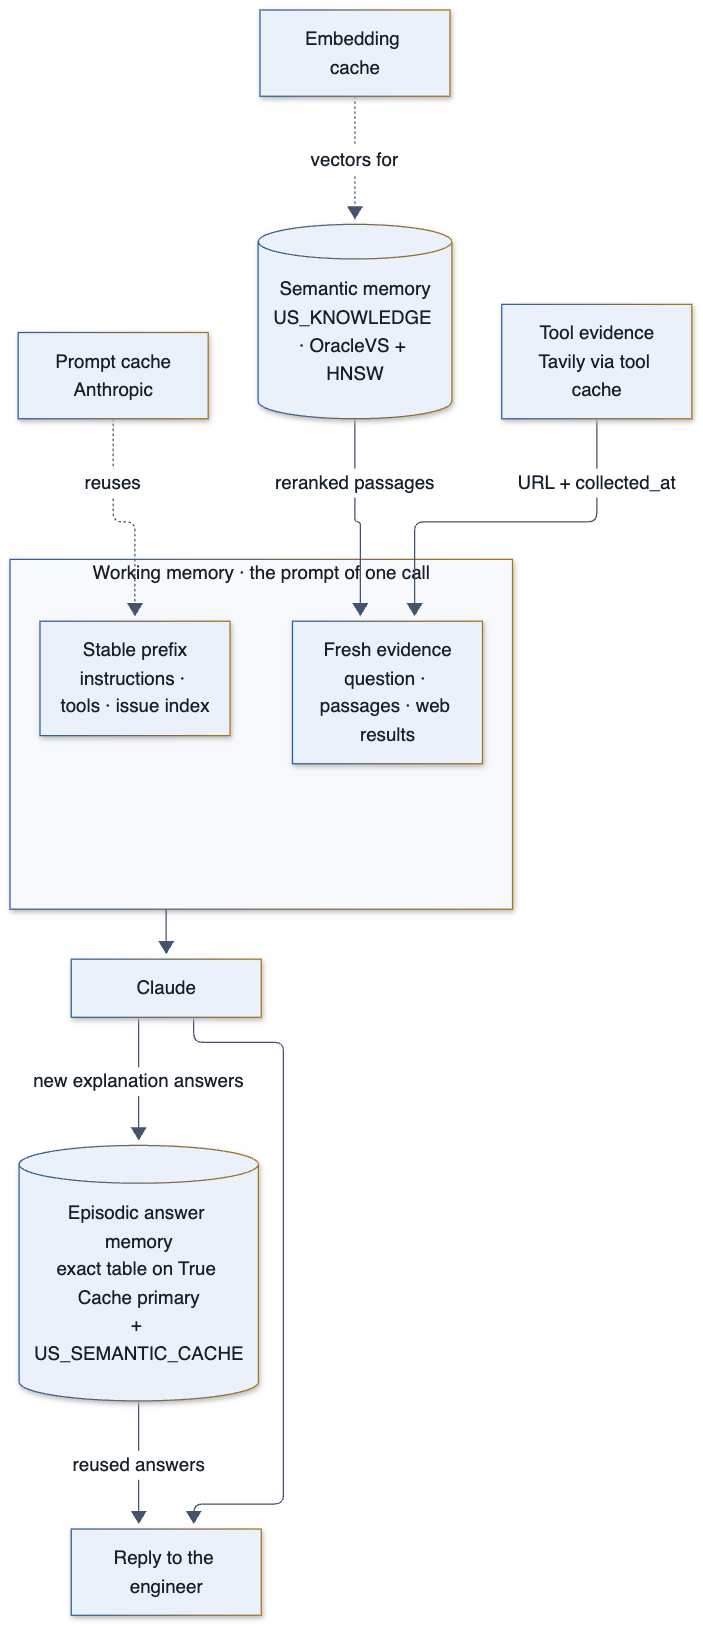

<details><summary>Mermaid source</summary>

```mermaid
flowchart TB
    subgraph WM["Working memory · the prompt of one call"]
        Prefix["Stable prefix<br/>instructions · tools · issue index"]
        Evidence["Fresh evidence<br/>question · passages · web results"]
    end
    PC["Prompt cache<br/>Anthropic"] -.->|reuses| Prefix
    KB[("Semantic memory<br/>US_KNOWLEDGE · OracleVS + HNSW")] -->|reranked passages| Evidence
    EC["Embedding cache"] -.->|vectors for| KB
    Web["Tool evidence<br/>Tavily via tool cache"] -->|URL + collected_at| Evidence
    WM --> Claude["Claude"]
    Claude -->|new explanation answers| EP[("Episodic answer memory<br/>exact table on True Cache primary<br/>+ US_SEMANTIC_CACHE")]
    EP -->|reused answers| Reply["Reply to the engineer"]
    Claude --> Reply
```

</details>

### Takeaways

- The knowledge base is the memory of record; cached answers are computed from it and must be invalidated with it.
- The prompt cache and embedding cache change cost, never content.
- Web evidence is working memory with provenance; the tool cache keeps it only briefly.
- Each layer maps to one kind of memory, which tells you what may be reused and for how long.

# Part 3 · Set up

## 3.1 · Imports

The first cell holds the standard-library imports. `TOKENIZERS_PARALLELISM=false` stops the Hugging Face
tokenizer from printing a fork warning when the notebook runs other work after encoding.

In [2]:
import hashlib
import json
import os
import time
import uuid
from getpass import getpass

os.environ["TOKENIZERS_PARALLELISM"] = "false"

The second cell holds the libraries: the raw Anthropic SDK for Claude, `oracledb` (thin mode, no Oracle
client install) for both databases, `langchain-oracledb` for `OracleVS` and `OracleSemanticCache`,
`sentence-transformers` for the local encoder and reranker, `tavily` for web search, and pandas and
matplotlib for the results. LangChain is used only for its storage components; generation stays on the raw
Anthropic client.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import oracledb
import pandas as pd
from anthropic import Anthropic
from IPython.display import display
from langchain_core.embeddings import Embeddings
from langchain_core.outputs import Generation
from langchain_oracledb import OracleSemanticCache
from langchain_oracledb.vectorstores import DistanceStrategy, OracleVS
from langchain_oracledb.vectorstores.oraclevs import create_index
from sentence_transformers import CrossEncoder, SentenceTransformer
from tavily import TavilyClient

Every row this run writes is tagged with a short **run id**, so a second run never sees the first run's
cache entries and the cleanup at the end removes exactly what this run created.

In [4]:
RUN_ID = uuid.uuid4().hex[:8]
pd.set_option("display.max_colwidth", 90)
print("Run id:", RUN_ID)

Run id: 5ba303a0


## 3.2 · Keys, Claude and the vector schema

### Read private keys safely

`secret()` asks for a key with `getpass`, so the value is never echoed into the notebook
or saved with its outputs. Automated runs can set `NOTEBOOK_USE_ENV_KEYS=1` to read the
same name from an environment variable instead. An empty value stops the notebook early
with a clear error rather than failing later inside a provider call.

In [5]:
def secret(name):
    """Return a private key from a hidden prompt, or from the environment in automated runs."""
    if os.getenv("NOTEBOOK_USE_ENV_KEYS") == "1":
        value = os.getenv(name, "")
    else:
        value = getpass(f"Enter {name}: ")
    if not value.strip():
        raise ValueError(f"{name} is required.")
    return value.strip()

### Price every Claude call from reported usage

Every response from the Anthropic API reports how many tokens it processed. The prices below
are the published list prices for Claude Opus 5.5 (USD per million tokens, checked on
2026-10-03). Each counter is priced separately:

- `input`: ordinary prompt tokens.
- `cache_write`: prompt tokens written to Anthropic's prompt cache (1.25× input).
- `cache_read`: prompt tokens read back from that cache (0.05× input on Opus 5.5).
- `output`: generated tokens, the most expensive counter.

`LLM_CALLS` is a ledger: one row per real request, so every cost in this notebook can be
traced back to an actual API response. These are list-price estimates, not an invoice.

In [6]:
MODEL = "claude-opus-5-5"
PRICE = {"input": 4.00, "cache_write": 5.00, "cache_read": 0.20, "output": 20.00}
LLM_CALLS = []


def llm_cost(usage):
    """Price one response from the token counters the API returned."""
    tokens = {
        "input": usage.input_tokens,
        "cache_write": usage.cache_creation_input_tokens or 0,
        "cache_read": usage.cache_read_input_tokens or 0,
        "output": usage.output_tokens,
    }
    return tokens, sum(tokens[k] * PRICE[k] for k in tokens) / 1_000_000

### One function for every model call

`ask_claude()` sends a single request with the raw Anthropic SDK. `system` is either a plain
string or a list of content blocks (the list form is what lets a block carry a prompt-cache
breakpoint). `effort="low"` asks the model for a direct answer, which keeps latency and
output tokens down. The function records latency, the four token counters and the estimated
cost in `LLM_CALLS`, then returns only the visible text.

In [7]:
def ask_claude(system, user, max_tokens=1024):
    """Send one request, record latency, tokens and cost, and return the answer text."""
    started = time.perf_counter()
    response = claude.messages.create(
        model=MODEL,
        max_tokens=max_tokens,
        system=system,
        messages=[{"role": "user", "content": user}],
        output_config={"effort": "low"},
    )
    tokens, usd = llm_cost(response.usage)
    seconds = time.perf_counter() - started
    LLM_CALLS.append({"seconds": seconds, **tokens, "usd": usd})
    return "".join(b.text for b in response.content if b.type == "text")

Create the client. The key is read with `secret()`; the client object keeps it in memory
only. A timeout and two retries keep a slow network from hanging the notebook.

In [8]:
claude = Anthropic(api_key=secret("ANTHROPIC_API_KEY"), timeout=120, max_retries=2)

### Connect to Oracle AI Database

The cache tables live in a **dedicated application schema**. `oracle_connection()` reads
`ORACLE_USER`, `ORACLE_PASSWORD` and `ORACLE_DSN` from the environment and prompts for any
that are missing (the password prompt is hidden). It refuses `SYS` and `SYSTEM`: an
application cache should never run with administrator privileges. The schema needs
`CREATE TABLE` and a tablespace quota; vector features need Oracle AI Database 23ai or later.

In [9]:
def oracle_connection():
    """Connect to a dedicated schema; administrator accounts are refused."""
    user = os.getenv("ORACLE_USER") or input("Oracle user: ").strip()
    password = os.getenv("ORACLE_PASSWORD") or getpass("Oracle password: ")
    dsn = os.getenv("ORACLE_DSN") or input("Oracle DSN (host:port/service): ").strip()
    if user.lower() in {"sys", "system"}:
        raise ValueError("Use a dedicated application schema.")
    return oracledb.connect(user=user, password=password, dsn=dsn)


conn = oracle_connection()
print("Connected to Oracle", conn.version)

Connected to Oracle 23.26.2.0.0


`create_if_missing()` makes the DDL in this notebook safe to re-run. Oracle raises
`ORA-00955` when an object name already exists; only that error is ignored. Anything else,
such as a missing privilege or an exhausted vector memory pool, is raised so you can see it.

In [10]:
def create_if_missing(sql):
    """Run DDL, ignoring only 'name is already used by an existing object'."""
    with conn.cursor() as cursor:
        try:
            cursor.execute(sql)
        except oracledb.DatabaseError as error:
            if error.args[0].code != 955:
                raise

## 3.3 · Connect to the Oracle True Cache pair

**Oracle True Cache** is a read-only, in-memory Oracle instance that sits in front of a primary database.
It is populated on demand from the primary and kept current by applying the primary's redo, so the
application never writes invalidation code for it. The application uses **two connections**:

- `tc_primary` to the primary database service: every write goes here.
- `tc_reader` to the True Cache service: lookups go here, offloading the primary.

The four settings come from `TRUE_CACHE_USER`, `TRUE_CACHE_PASSWORD`, `PRIMARY_DSN` and `TRUE_CACHE_DSN`;
anything missing is prompted for, with the password hidden. The user is an ordinary application user on the
primary; True Cache replicates users and data, so the same credentials work on both services.

In [11]:
def true_cache_pair():
    """Open one connection for writes (primary) and one for reads (True Cache)."""
    user = os.getenv("TRUE_CACHE_USER") or input("True Cache user: ").strip()
    password = os.getenv("TRUE_CACHE_PASSWORD") or getpass("Application password: ")
    primary_dsn = os.getenv("PRIMARY_DSN") or input("Primary DSN: ").strip()
    reader_dsn = os.getenv("TRUE_CACHE_DSN") or input("True Cache DSN: ").strip()
    primary = oracledb.connect(user=user, password=password, dsn=primary_dsn)
    reader = oracledb.connect(user=user, password=password, dsn=reader_dsn)
    return primary, reader


tc_primary, tc_reader = true_cache_pair()

Ask each connection which role its database plays. **What to watch:** the write connection reports
`PRIMARY`; the read connection reports the standby-style role that True Cache presents to sessions.

In [12]:
def database_role(connection):
    with connection.cursor() as cursor:
        cursor.execute("SELECT sys_context('userenv', 'database_role') FROM dual")
        return cursor.fetchone()[0]


print("writes go to:", database_role(tc_primary))
print("reads go to: ", database_role(tc_reader))

writes go to: PRIMARY
reads go to:  PHYSICAL STANDBY


## 3.4 · The local models

### Load the open-source embedding model

Embeddings come from [`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2), a small
open-source model from Hugging Face that runs locally on the CPU. It maps text to a
384-dimensional vector. Pinning the **revision** (a commit hash in the model repository)
matters for caching: if the model files change, the vectors change, and every stored vector
must be treated as stale. The first run downloads about 90 MB; later runs load from the
local Hugging Face cache. No API key is needed and no text leaves your machine.

In [13]:
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
EMBED_REVISION = "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"
encoder = SentenceTransformer(EMBED_MODEL, revision=EMBED_REVISION, device="cpu")
EMBED_DIM = encoder.get_embedding_dimension()
print(EMBED_MODEL, "→", EMBED_DIM, "dimensions")

sentence-transformers/all-MiniLM-L6-v2 → 384 dimensions


### Load the open-source reranker

A **reranker** is a cross-encoder: it reads two texts *together* and returns one relevance
score, which is slower than comparing two precomputed vectors but much better at telling
"same question" from "similar words". This notebook uses
[`cross-encoder/ms-marco-MiniLM-L-6-v2`](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2), also local and pinned to a
revision. Its scores are unbounded logits: higher means more relevant, and values above
zero mean the model leans towards "relevant".

In [14]:
RERANK_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
RERANK_REVISION = "233902d25c440f23af6f7d6e94d2946bac0bee0a"
reranker = CrossEncoder(RERANK_MODEL, revision=RERANK_REVISION, device="cpu")
print("Reranker ready:", RERANK_MODEL)

Reranker ready: cross-encoder/ms-marco-MiniLM-L-6-v2


## 3.5 · The web-search tool and its ledger

`web_search()` calls Tavily once and records the latency and the **credits** Tavily reports
(`include_usage=True`) in `TOOL_CALLS`. Credits are priced at the pay-as-you-go list rate, configurable
with `TAVILY_USD_PER_CREDIT`. If Tavily does not report credits, the cost stays unknown (`None`) instead
of being guessed. Each result is stamped with `collected_at`, the moment the evidence was gathered.

In [15]:
TAVILY_USD_PER_CREDIT = float(os.getenv("TAVILY_USD_PER_CREDIT", "0.008"))
TOOL_CALLS = []
tavily = TavilyClient(api_key=secret("TAVILY_API_KEY"))


def web_search(query, max_results=3):
    """Call Tavily once; record latency and reported credits."""
    started = time.perf_counter()
    found = tavily.search(query=query, max_results=max_results, include_usage=True)
    credits = (found.get("usage") or {}).get("credits")
    usd = credits * TAVILY_USD_PER_CREDIT if credits is not None else None
    TOOL_CALLS.append({"seconds": time.perf_counter() - started, "usd": usd})
    return {"results": found.get("results", []), "collected_at": time.time()}

## 3.6 · Load the knowledge base data

The knowledge base is the Django part of [SWE-bench Lite](https://huggingface.co/datasets/SWE-bench/SWE-bench_Lite):
real GitHub issues that were later fixed, each with the issue text as the reporter wrote it. The parquet
file is read straight from Hugging Face with pandas, **pinned to a dataset revision** so the content never
changes under the notebook. Only the three needed columns are read. The first line of each issue serves as
its title.

In [16]:
SWE_BENCH = (
    "hf://datasets/SWE-bench/SWE-bench_Lite@b0dde1093fe417d83b7184254edf8199c1f0dff5"
    "/data/test-00000-of-00001.parquet"
)
issues = pd.read_parquet(
    SWE_BENCH, columns=["instance_id", "repo", "problem_statement"]
)
issues = issues[issues.repo == "django/django"].sort_values("instance_id")
issues = issues.reset_index(drop=True)
issues["title"] = issues.problem_statement.str.strip().str.split("\n").str[0].str[:120]
print(len(issues), "resolved Django issues")
display(issues[["instance_id", "title"]].head())

114 resolved Django issues


,instance_id,title
0,django__django-10914,Set default FILE_UPLOAD_PERMISSION to 0o644.
1,django__django-10924,Allow FilePathField path to accept a callable.
2,django__django-11001,Incorrect removal of order_by clause created as multiline RawSQL
3,django__django-11019,Merging 3 or more media objects can throw unnecessary MediaOrderConflictWarnings
4,django__django-11039,sqlmigrate wraps it's outpout in BEGIN/COMMIT even if the database doesn't support tra...


### Takeaways

- Two Oracle connections serve the exact cache: writes to the primary, reads through True Cache.
- The encoder and reranker run locally; only Claude and Tavily calls leave the machine.
- Every paid call lands in a ledger (`LLM_CALLS`, `TOOL_CALLS`), so every cost below traces to a real response.

# Part 4 · Build the layers

## 4.1 · Layer 2 · local encoding and the embedding cache

The embedding layer is built first because every other vector component uses it. `encode()` runs the local
encoder on a batch of texts and appends one row to `ENCODER_RUNS` with the number of texts it actually
embedded. Vectors are **normalised**, so cosine distance between them is meaningful. `embedding_key()` is the
identity of a vector: model, revision, normalisation and the exact text. Anything that changes the vector
must be in that key.

In [17]:
ENCODER_RUNS = []


def encode(texts):
    """Embed a batch locally and record how many texts the encoder actually processed."""
    started = time.perf_counter()
    vectors = encoder.encode(texts, normalize_embeddings=True, convert_to_numpy=True)
    ENCODER_RUNS.append({"texts": len(texts), "seconds": time.perf_counter() - started})
    return [vector.astype(np.float32).tolist() for vector in vectors]


def embedding_key(text):
    """A vector's identity: model, revision, normalisation and the exact text."""
    raw = json.dumps([EMBED_MODEL, EMBED_REVISION, "normalized", text])
    return hashlib.sha256(raw.encode()).hexdigest()

`LocalEmbeddings` adapts the encoder to LangChain's `Embeddings` interface, which is what `OracleVS` and
`OracleSemanticCache` call. Passing a dictionary as `cache` switches the embedding cache on:

- `embed_documents()` finds which texts have no stored vector, encodes only those **in one batch**, stores
  them, and counts every text served from the dictionary in `hits`.
- `embed_query()` is the same path for one text.

With `cache=None` every call reaches the encoder, which is the uncached behaviour the baseline needs.

In [18]:
class LocalEmbeddings(Embeddings):
    """LangChain adapter for the local encoder; a dict passed as `cache` turns caching on."""

    def __init__(self, cache=None):
        self.cache, self.hits = cache, 0

    def embed_documents(self, texts):
        if self.cache is None:
            return encode(texts)
        new = [t for t in dict.fromkeys(texts) if embedding_key(t) not in self.cache]
        if new:
            self.cache.update(zip(map(embedding_key, new), encode(new)))
        self.hits += len(texts) - len(new)
        return [self.cache[embedding_key(t)] for t in texts]

    def embed_query(self, text):
        return self.embed_documents([text])[0]

## 4.2 · The knowledge base in Oracle AI Database

`OracleVS` stores each issue as a row with its text, a JSON metadata column and a `VECTOR(384, FLOAT32)`
column, in the table `US_KNOWLEDGE`. `add_texts()` embeds the issues and upserts them
(`mutate_on_duplicate=True`), keyed by the issue id, so re-running this cell updates rows instead of
duplicating them. The encoder reads at most 256 word pieces of each issue, which covers the title and the
description of the problem.

`create_index()` then builds an **HNSW** vector index (an in-memory neighbour graph with cosine distance and
a target accuracy of 95%), which lets a query find the nearest issues without comparing against every row.
The index is created only if it does not already exist.

In [19]:
knowledge = OracleVS(
    conn,
    LocalEmbeddings(),
    "US_KNOWLEDGE",
    DistanceStrategy.COSINE,
    mutate_on_duplicate=True,
)
texts = issues.problem_statement.str.strip().tolist()
metadatas = issues[["instance_id", "title"]].to_dict("records")
stored = knowledge.add_texts(
    texts, metadatas=metadatas, ids=issues.instance_id.tolist()
)
print(len(stored), "issues embedded and upserted into US_KNOWLEDGE")

114 issues embedded and upserted into US_KNOWLEDGE


Build the HNSW index and confirm the row count. **What to watch:** all 114 issues are in the table.

In [20]:
HNSW = {"idx_name": "US_KNOWLEDGE_HNSW", "idx_type": "HNSW", "accuracy": 95}
create_index(conn, knowledge, HNSW)
with conn.cursor() as cursor:
    cursor.execute("SELECT COUNT(*) FROM US_KNOWLEDGE")
    print("Issues in US_KNOWLEDGE:", cursor.fetchone()[0])

Issues in US_KNOWLEDGE: 114


### Retrieval with a reranker

Vector search is fast but coarse: it compares two vectors computed separately. The **reranker** reads the
question and each candidate issue *together*, which is slower but much better at judging relevance. The
standard pattern combines them:

1. `similarity_search()` asks the HNSW index for the `k=6` nearest issues (approximate, fast).
2. The reranker scores each `(question, issue)` pair.
3. Only passages with a positive score are kept, at most `keep=2`; if none is positive, the single best one
   is kept so the model still sees the closest evidence.

Fewer, better passages keep the prompt short, which lowers cost on every uncached call.

In [21]:
def passage(score, document):
    return {
        "issue": document.metadata["instance_id"],
        "rerank": round(float(score), 2),
        "text": document.page_content[:1500],
    }


def retrieve(store, question, k=6, keep=2):
    """HNSW finds k candidates; the cross-encoder keeps the passages it scores best."""
    candidates = store.similarity_search(question, k=k)
    scores = reranker.predict([(question, d.page_content[:2000]) for d in candidates])
    ranked = sorted(zip(scores, candidates), key=lambda pair: -pair[0])
    chosen = [pair for pair in ranked if pair[0] > 0][:keep] or ranked[:1]
    return [passage(score, document) for score, document in chosen]

Try it on the question the workload will ask. **What to watch:** the issue about `FileBasedCache.has_key`
comes back first with a clearly positive reranker score; unrelated issues are dropped.

In [22]:
QUESTION = "Why is FileBasedCache.has_key in Django susceptible to race conditions?"
for found in retrieve(knowledge, QUESTION):
    print(found["issue"], found["rerank"], "·", found["text"][:90].replace("\n", " "))

django__django-16379 7.53 · FileBasedCache has_key is susceptible to race conditions Description 	  		(last modified b


## 4.3 · The stable prompt prefix

Everything that is the same on every call goes into one **stable prefix**: the instructions, a description
of the agent's tools, and an index of every issue in the knowledge base (id and title). The index lets the
model name related issues even when retrieval returns only one or two passages. Only the question and its
evidence change from call to call, and they come after the prefix.

The prefix must be comfortably longer than Anthropic's minimum cacheable length, or prompt caching
silently does nothing. The token-counting endpoint (free, no generation) reports its exact size.

In [23]:
INSTRUCTIONS = (
    "You are a developer-support agent for the Django web framework. Answer in at most "
    "120 words. Use only the supplied evidence: knowledge-base issues (cite their ids, "
    "for example django__django-16379) and web results (cite their URLs and say when they "
    "were collected). If the evidence does not answer the question, say so."
)
TOOLS = (
    "Tools: knowledge_base(question) searches resolved Django issues in Oracle (HNSW, "
    "then a reranker). web_search(query) is a read-only Tavily search whose results may "
    "be up to 120 seconds old; it is used only for questions about current releases."
)
INDEX = "\n".join(f"- {i}: {t}" for i, t in zip(issues.instance_id, issues.title))
PREFIX = f"{INSTRUCTIONS}\n\n{TOOLS}\n\nKnown resolved Django issues:\n{INDEX}"

Count the prefix with the token-counting endpoint. It returns the number of input tokens the request would
use, without generating anything.

In [24]:
counted = claude.messages.count_tokens(
    model=MODEL, system=PREFIX, messages=[{"role": "user", "content": "ping"}]
)
print(f"Stable prefix: {len(PREFIX):,} characters, {counted.input_tokens:,} tokens")

Stable prefix: 11,013 characters, 3,886 tokens


**What to watch:** the prefix is a few thousand tokens. That is most of the input of every call, so it is
exactly what prompt caching should absorb.

## 4.4 · Layer 1 · exact answers on Oracle True Cache

The exact cache is a table on the **primary**. `US_RESPONSE_CACHE` holds the key, the namespace (which
configuration wrote it), the question, the answer and an expiry time. The DDL runs on the primary; True
Cache receives the new table through redo like any other change. `ORA-00955` (name already used) is the only
error ignored, so a re-run reuses the table.

In [25]:
def create_response_table():
    """Create the exact-cache table on the primary; True Cache receives it from redo."""
    with tc_primary.cursor() as cursor:
        try:
            cursor.execute("""
                CREATE TABLE US_RESPONSE_CACHE (
                    cache_key  VARCHAR2(64) PRIMARY KEY,
                    namespace  VARCHAR2(64) NOT NULL,
                    question   VARCHAR2(4000) NOT NULL,
                    answer     CLOB NOT NULL,
                    expires_at TIMESTAMP WITH TIME ZONE NOT NULL)""")
        except oracledb.DatabaseError as error:
            if error.args[0].code != 955:
                raise

`wait_for_true_cache()` polls the True Cache connection until a statement that works on the primary also
works there, and returns how long that took. On a first run this measures how quickly the new table
became visible through True Cache; on later runs the table is already there and the wait is close to zero.

In [26]:
def wait_for_true_cache(sql, timeout=30):
    """Retry a read on True Cache until it succeeds; return the seconds it took."""
    started = time.perf_counter()
    while True:
        try:
            with tc_reader.cursor() as cursor:
                cursor.execute(sql)
                return time.perf_counter() - started
        except oracledb.DatabaseError:
            if time.perf_counter() - started > timeout:
                raise
            time.sleep(0.1)


create_response_table()
seconds = wait_for_true_cache("SELECT COUNT(*) FROM US_RESPONSE_CACHE")
print(f"US_RESPONSE_CACHE readable through True Cache after {seconds:.2f} s")

US_RESPONSE_CACHE readable through True Cache after 0.01 s


The **key** is a SHA-256 hash of the namespace, the model and the exact question. The namespace stands for
everything else that shaped the answer: the prompt prefix version and the configuration. Two questions that
differ by one character get different keys; that is the point of an *exact* cache.

In [27]:
def response_key(namespace, question):
    """Exact identity: namespace (prompt version, configuration), model, exact question."""
    raw = json.dumps({"namespace": namespace, "model": MODEL, "question": question})
    return hashlib.sha256(raw.encode()).hexdigest()

A lookup reads the key **through True Cache first**, accepting only rows whose `expires_at` is in the future.
If True Cache has no row, the primary is asked once: True Cache applies the primary's redo continuously, but
a read that arrives a fraction of a second after a write can come before the row is applied. A primary read
costs milliseconds; the model call it can prevent costs seconds and real money. `exact_lookup()` returns the
answer and the tier that served it (`true_cache` or `primary`).

In [28]:
READ_SQL = """
    SELECT answer FROM US_RESPONSE_CACHE
    WHERE cache_key = :cache_key AND expires_at > SYSTIMESTAMP"""


def read_answer(connection, key):
    """Return the stored answer for an unexpired key on one connection, or None."""
    with connection.cursor() as cursor:
        cursor.execute(READ_SQL, cache_key=key)
        row = cursor.fetchone()
        value = row[0] if row else None
        return value.read() if hasattr(value, "read") else value

`exact_lookup()` tries the two tiers in order and reports which one answered.

In [29]:
def exact_lookup(key):
    """Read through True Cache; on a miss, ask the primary before calling the model."""
    for tier, connection in [("true_cache", tc_reader), ("primary", tc_primary)]:
        answer = read_answer(connection, key)
        if answer is not None:
            return answer, tier
    return None, None

`exact_store()` writes **only to the primary**, with a `MERGE` so that storing the same key again updates
the row. Two workers storing the same new key at the same moment would both take the insert branch; the
second fails with `ORA-00001` once the first commits, and `merge_once()` below treats that as success. Each value is bound once, inside the `USING` row, and referenced from both the
`UPDATE` and the `INSERT` branch; the answer is bound as a `CLOB`. The expiry is computed by the database
(`SYSTIMESTAMP` plus the TTL), so every reader compares against the same clock.

In [30]:
WRITE_SQL = """
    MERGE INTO US_RESPONSE_CACHE d
    USING (SELECT :cache_key cache_key, :namespace namespace, :question question,
                  :answer answer, :ttl ttl FROM dual) s
    ON (d.cache_key = s.cache_key)
    WHEN MATCHED THEN UPDATE SET d.answer = s.answer,
        d.expires_at = SYSTIMESTAMP + NUMTODSINTERVAL(s.ttl, 'SECOND')
    WHEN NOT MATCHED THEN INSERT (cache_key, namespace, question, answer, expires_at)
        VALUES (s.cache_key, s.namespace, s.question, s.answer,
                SYSTIMESTAMP + NUMTODSINTERVAL(s.ttl, 'SECOND'))"""

`merge_once()` runs one upsert and absorbs exactly one error: `ORA-00001` (error code 1), the unique-key
violation a worker gets when another worker inserted the same key first. The row it wanted to store
already exists, so that is success. Any other database error is raised.

In [31]:
def merge_once(cursor, sql, binds):
    """Run an upsert MERGE; if another worker inserted the same key first, its row stands."""
    try:
        cursor.execute(sql, binds)
    except oracledb.IntegrityError as error:
        if error.args[0].code != 1:  # anything other than ORA-00001 is a real failure
            raise

`exact_store()` runs that statement on the primary connection and commits. `setinputsizes()` declares the
answer as a `CLOB`, so long answers bind correctly.

In [32]:
def exact_store(key, namespace, question, answer, ttl=300):
    """Write to the primary only; True Cache applies the row from redo."""
    values = dict(cache_key=key, namespace=namespace, question=question, ttl=ttl)
    with tc_primary.cursor() as cursor:
        cursor.setinputsizes(answer=oracledb.DB_TYPE_CLOB)
        merge_once(cursor, WRITE_SQL, dict(values, answer=answer))
    tc_primary.commit()

Check the layer on its own before wiring it into the stack: store a probe answer, read it back at once, then
again one second later. **What to watch:** the immediate read may be served by `primary` (True Cache had not
applied the write yet) or already by `true_cache`; after a one-second pause it is served by `true_cache`.
The probe row belongs to this run and is removed in the cleanup.

In [33]:
probe_namespace = f"{RUN_ID}-probe"
probe_key = response_key(probe_namespace, "probe question")
exact_store(probe_key, probe_namespace, "probe question", "probe answer")
print("read at once: ", exact_lookup(probe_key))
time.sleep(1)
print("after 1 second:", exact_lookup(probe_key))

read at once:  ('probe answer', 'primary')


after 1 second: ('probe answer', 'true_cache')


## 4.5 · Layer 3 · semantic answers with `OracleSemanticCache`

`OracleSemanticCache` (from `langchain-oracledb`) stores each cached question as a vector row in one table,
`US_SEMANTIC_CACHE`, with an HNSW index. Its `lookup(prompt, llm_string)` embeds the new question, searches
only the rows written under the same `llm_string`, and returns the stored value if the nearest row is within
`score_threshold` (a **cosine distance**: lower is closer). Here `llm_string` is the configuration's
namespace, so configurations never read each other's answers.

The policy has **two checks**, matching the calibration in the semantic-cache notebook of this folder:

- distance **≤ 0.35** from the HNSW search, which lets real paraphrases through, and
- a **reranker score ≥ 0** for the pair (new question, cached question), which rejects many near misses that
  share words but ask something else.

In [34]:
SEMANTIC_THRESHOLD = 0.35
RERANK_MIN = 0.0


def semantic_cache(embeddings):
    """One shared table and HNSW index; each configuration writes its own namespace."""
    return OracleSemanticCache(
        conn,
        embeddings,
        "US_SEMANTIC_CACHE",
        distance_strategy=DistanceStrategy.COSINE,
        score_threshold=SEMANTIC_THRESHOLD,
        create_index_if_missing=True,
        index_name="US_SEMANTIC_HNSW",
        index_params={"idx_type": "HNSW", "accuracy": 95},
    )

`OracleSemanticCache` returns the stored value but not the question it was stored under, and the reranker
needs that question. So the stored value is a small JSON **envelope**: the original question, the answer and
an expiry time (the cache itself has no TTL; the application adds it).

- `semantic_store()` writes the envelope as a LangChain `Generation`.
- `semantic_lookup()` parses the envelope of the nearest match, rejects it if it has expired, and scores
  `(new question, cached question)` with the reranker. It returns the envelope (or `None`) and the score.

In [35]:
def semantic_store(stack, question, answer, ttl=300):
    """Store the answer with its original question and an expiry in a JSON envelope."""
    envelope = {"question": question, "answer": answer, "expires_at": time.time() + ttl}
    generation = Generation(text=json.dumps(envelope))
    stack["semantic"].update(question, stack["namespace"], [generation])


def semantic_lookup(stack, question):
    """Nearest cached question within the threshold, then a reranker check of the pair."""
    found = stack["semantic"].lookup(question, stack["namespace"])
    if not found:
        return None, None
    envelope = json.loads(found[0].text)
    score = float(reranker.predict([(question, envelope["question"])])[0])
    fresh = envelope["expires_at"] > time.time()
    return (envelope if fresh and score >= RERANK_MIN else None), round(score, 2)

## 4.6 · Layer 4 · the prompt-cache breakpoint

Prompt caching needs no storage code: it is one field. `system_blocks()` sends the stable prefix as a single
system block; with the layer switched on, that block carries `cache_control: {"type": "ephemeral"}`, a
**breakpoint** that tells Anthropic to cache everything up to and including it for five minutes. The
question and evidence travel in the user message, after the breakpoint, so they can change freely.

In [36]:
def system_blocks(stack):
    """The stable prefix as one block; with prompt caching on, it ends in a breakpoint."""
    block = {"type": "text", "text": stack["prefix"]}
    if stack["features"]["prompt"]:
        block["cache_control"] = {"type": "ephemeral"}
    return [block]

## 4.7 · Layer 5 · the tool-result cache

`cached_search()` wraps the read-only web search. The key is the tool version, the configuration's
namespace (standing in for the owner), the trimmed query and `max_results`: everything that changes the
result. A stored entry is served only before its expiry (120 seconds), and it is returned **unchanged**,
including its original `collected_at`. Empty results are not stored, so a transient failure does not stick.
The function returns the result and whether it was a cache hit.

In [37]:
TOOL_VERSION = "tavily-search-v1"


def cached_search(stack, query, max_results=3, ttl=120):
    """Read-only web search through a short-TTL cache that keeps collected_at."""
    identity = [TOOL_VERSION, stack["namespace"], query.strip(), max_results]
    key = hashlib.sha256(json.dumps(identity).encode()).hexdigest()
    cache = stack["tool_cache"]
    entry = cache.get(key) if cache is not None else None
    if entry and entry["expires"] > time.time():
        return entry["result"], True
    result = web_search(query, max_results)
    if cache is not None and result["results"]:
        cache[key] = {"result": result, "expires": time.time() + ttl}
    return result, False

## 4.8 · Assemble the stack

`new_stack(features)` builds one configuration from a dictionary of on/off switches, with nothing carried
over from earlier configurations:

- a fresh **embedding cache** (an empty dictionary) or none,
- a fresh **namespace** for the exact and semantic answer caches,
- a **unique marker** at the very start of the prompt prefix, so this configuration's first call cannot
  read a prefix that an earlier configuration wrote to Anthropic's cache,
- a knowledge-base view (`OracleVS` over `US_KNOWLEDGE`) that embeds queries through this configuration's
  adapter, a semantic cache if that layer is on, and a fresh tool cache if that layer is on.

In [38]:
FEATURES = ["exact", "embedding", "semantic", "prompt", "tool"]


def knowledge_view(embeddings):
    """US_KNOWLEDGE seen through one configuration's embedding adapter."""
    return OracleVS(conn, embeddings, "US_KNOWLEDGE", DistanceStrategy.COSINE)

The stack itself is a plain dictionary, so every layer function can read the switches and its own store.

In [39]:
def new_stack(features):
    """Fresh caches, a fresh namespace and a unique prefix marker for one configuration."""
    marker = uuid.uuid4().hex[:12]
    embeddings = LocalEmbeddings({} if features["embedding"] else None)
    return {
        "features": features,
        "namespace": f"{RUN_ID}-{marker}",
        "prefix": f"Configuration marker: {marker}\n\n{PREFIX}",
        "embeddings": embeddings,
        "knowledge": knowledge_view(embeddings),
        "semantic": semantic_cache(embeddings) if features["semantic"] else None,
        "tool_cache": {} if features["tool"] else None,
    }

The answer layers come first on a request. `reuse()` tries layer 1, then layer 3, and returns a result with
`served_by` naming the layer (and, for the exact layer, the tier) or `None` when the model has to answer.
`remember()` stores a fresh answer in every answer layer that is switched on.

In [40]:
def reuse(stack, key, question):
    """Layers 1 and 3: a stored answer, or None when the model has to answer."""
    if stack["features"]["exact"]:
        answer, tier = exact_lookup(key)
        if answer is not None:
            return {"answer": answer, "served_by": f"exact · {tier}"}
    if stack["features"]["semantic"]:
        envelope, score = semantic_lookup(stack, question)
        if envelope:
            return {"answer": envelope["answer"], "served_by": f"semantic · {score}"}
    return None

`remember()` stores a fresh explanation answer in every answer layer that is switched on: the exact table
on the primary and the semantic cache.

In [41]:
def remember(stack, key, question, answer):
    """Store a fresh explanation answer in every answer layer that is on."""
    if stack["features"]["exact"]:
        exact_store(key, stack["namespace"], question, answer)
    if stack["features"]["semantic"]:
        semantic_store(stack, question, answer)

When no stored answer applies, `generate()` gathers evidence and calls Claude:

- knowledge-base passages for every request (HNSW plus reranker, through this configuration's embeddings),
- for live requests, web results through the tool cache, trimmed to title, URL and a short excerpt, plus
  the time they were collected,
- then one Claude call with the system blocks (stable prefix, possibly with a breakpoint) and the question
  and evidence as JSON in the user message.

It returns the answer and whether the web results came from the tool cache.

In [42]:
def web_evidence(result):
    keep = ("title", "url", "content")
    pages = [{k: r.get(k, "")[:600] for k in keep} for r in result["results"]]
    stamp = time.strftime("%Y-%m-%d %H:%M:%S UTC", time.gmtime(result["collected_at"]))
    return {"collected_at": stamp, "pages": pages}


def generate(stack, request):
    """Gather evidence (knowledge base, plus the web for live requests) and ask Claude."""
    evidence = {"knowledge_base": retrieve(stack["knowledge"], request["question"])}
    tool_hit = None
    if request["kind"] == "live":
        result, tool_hit = cached_search(stack, request["question"])
        evidence["web"] = web_evidence(result)
    user = json.dumps({"question": request["question"], "evidence": evidence}, indent=1)
    return ask_claude(system_blocks(stack), user, max_tokens=400), tool_hit

`handle()` walks the layers for one request. Only explanations may reuse or store an answer; a live request
goes straight to evidence and generation. This one function is the whole runtime policy of the stack.

In [43]:
def handle(stack, request):
    """Walk the layers for one request; live requests never reuse or store an answer."""
    reusable = request["kind"] == "explanation"
    key = response_key(stack["namespace"], request["question"])
    found = reuse(stack, key, request["question"]) if reusable else None
    if found:
        return found
    answer, tool_hit = generate(stack, request)
    if reusable:
        remember(stack, key, request["question"], answer)
    return {"answer": answer, "served_by": "model", "tool_hit": tool_hit}

## 4.9 · Measure one request

`usage_since()` sums the three ledgers from a starting position: Claude calls with their four token
counters, texts the encoder actually embedded, embedding-cache hits, and tool calls. The estimated cost
is the sum of the Claude and Tavily list-price estimates; if any Tavily cost is unknown, the total is
reported as unknown rather than understated. Local encoder and reranker work has no API price; its cost is
the time already included in the latency.

In [44]:
def usage_since(marks, hits_before, stack):
    """Sum the ledgers since `marks`: model calls, encoder runs, tool calls, costs."""
    llm, runs = LLM_CALLS[marks[0] :], ENCODER_RUNS[marks[1] :]
    tools = TOOL_CALLS[marks[2] :]
    costs = [c["usd"] for c in llm] + [t["usd"] for t in tools]
    return {
        "llm_calls": len(llm),
        "encoder_runs": sum(r["texts"] for r in runs),
        "embedding_hits": stack["embeddings"].hits - hits_before,
        "tool_calls": len(tools),
        "cache_read_tokens": sum(c["cache_read"] for c in llm),
        "cache_write_tokens": sum(c["cache_write"] for c in llm),
        "estimated_usd": sum(costs) if None not in costs else None,
    }

`measure_request()` runs one request through a stack, times it, and appends one row to `MEASUREMENTS` with
the configuration, the request number, which layer served it, whether the web results were a tool-cache
hit, the latency and the usage above.

In [45]:
MEASUREMENTS = []


def measure_request(stage, number, request, stack):
    """Run one request through the stack and append one MEASUREMENTS row."""
    marks = (len(LLM_CALLS), len(ENCODER_RUNS), len(TOOL_CALLS))
    hits, started = stack["embeddings"].hits, time.perf_counter()
    result = handle(stack, request)
    seconds = round(time.perf_counter() - started, 3)
    row = {"stage": stage, "request": number, "kind": request["kind"]}
    row |= {"served_by": result["served_by"], "tool_hit": result.get("tool_hit")}
    MEASUREMENTS.append(row | {"seconds": seconds} | usage_since(marks, hits, stack))
    return result

### Takeaways

- Each layer is a small function with one job; `handle()` is the only place that decides the order.
- The exact layer writes to the primary and reads through True Cache, falling back to the primary once.
- The semantic layer accepts a match only if both the vector distance and the reranker agree.
- Configurations are isolated by namespace and prefix marker, so each one starts cold.

# Part 5 · Run the same workload under every configuration

## 5.1 · The workload

Six requests, fixed for every configuration, each chosen to exercise one layer:

1. An explanation question about a real issue in the knowledge base.
2. **The same question again**, word for word: the exact cache's case.
3. **A paraphrase** of it: the semantic cache's case.
4. **A different question** (migration optimiser): must miss every answer layer.
5. **A live question** about the latest Django release: always answered fresh, with web evidence.
6. **The same live question again**: the tool cache's case; the answer is still generated fresh.

The live question can be changed with the `STACK_LIVE_QUESTION` environment variable.

In [46]:
LIVE = os.getenv("STACK_LIVE_QUESTION", "What is new in the latest Django release?")
PARAPHRASE = "What makes the has_key method of Django's file-based cache prone to a race condition?"
OTHER = (
    "Why does Django's migration optimizer not reduce multiple AlterField operations?"
)
WORKLOAD = [
    {"kind": "explanation", "question": QUESTION},
    {"kind": "explanation", "question": QUESTION},
    {"kind": "explanation", "question": PARAPHRASE},
    {"kind": "explanation", "question": OTHER},
    {"kind": "live", "question": LIVE},
    {"kind": "live", "question": LIVE},
]

## 5.2 · The configurations

Six configurations, each adding one layer to the previous one: the uncached baseline, then exact, embedding,
semantic, prompt and tool caching.

In [47]:
STAGES = [("baseline", {name: False for name in FEATURES})]
for count, name in enumerate(FEATURES, start=1):
    STAGES.append((f"+ {name}", {f: i < count for i, f in enumerate(FEATURES)}))
display(pd.DataFrame({label: features for label, features in STAGES}).T)

,exact,embedding,semantic,prompt,tool
baseline,False,False,False,False,False
+ exact,True,False,False,False,False
+ embedding,True,True,False,False,False
+ semantic,True,True,True,False,False
+ prompt,True,True,True,True,False
+ tool,True,True,True,True,True


## 5.3 · Run it

For each configuration the loop builds a fresh stack (its setup time is recorded separately), then sends the
six requests in order. A one-second pause between requests stands in for the gap between two messages in a
chat; it is **not** part of any measured latency, and it is also enough time for True Cache to apply the
previous write. The loop prints which layer served each request.

**What to watch:**

- `baseline` sends every request to the model.
- From `+ exact` on, request 2 is served by `exact · true_cache` without a model call.
- From `+ semantic` on, request 3 (the paraphrase) is served by `semantic` with a positive reranker score,
  while request 4 still reaches the model.
- Requests 5 and 6 always reach the model, in every configuration.

In [48]:
PAUSE_SECONDS = 1.0
RESULTS, NAMESPACES, SETUP = {}, [], []
for label, features in STAGES:
    started = time.perf_counter()
    stack = new_stack(features)
    NAMESPACES.append(stack["namespace"])
    SETUP.append(
        {"stage": label, "setup_seconds": round(time.perf_counter() - started, 2)}
    )
    for number, request in enumerate(WORKLOAD, start=1):
        RESULTS[label, number] = measure_request(label, number, request, stack)
        time.sleep(PAUSE_SECONDS)
    print(f"{label:<12}", [RESULTS[label, n]["served_by"] for n in range(1, 7)])

baseline     ['model', 'model', 'model', 'model', 'model', 'model']


+ exact      ['model', 'exact · true_cache', 'model', 'model', 'model', 'model']


+ embedding  ['model', 'exact · true_cache', 'model', 'model', 'model', 'model']


+ semantic   ['model', 'exact · true_cache', 'semantic · 4.57', 'model', 'model', 'model']


+ prompt     ['model', 'exact · true_cache', 'semantic · 4.57', 'model', 'model', 'model']


+ tool       ['model', 'exact · true_cache', 'semantic · 4.57', 'model', 'model', 'model']


## 5.4 · Every request, every configuration

One row per request. **What to watch:**

- `encoder_runs` and `embedding_hits`: from `+ embedding` on, the repeated live question's vector comes from
  the cache; from `+ semantic` on, one question is embedded once but used three times (semantic lookup,
  retrieval, semantic store), so the hits climb while the runs stay low.
- `cache_read_tokens`: zero until `+ prompt`; from then on, the first model call of a configuration writes
  the prefix (`cache_write_tokens`) and later calls read it.
- `tool_hit`: `True` only for request 6 in the `+ tool` configuration.

In [49]:
frame = pd.DataFrame(MEASUREMENTS)
columns = ["stage", "request", "served_by", "seconds", "llm_calls", "encoder_runs"]
columns += [
    "embedding_hits",
    "tool_calls",
    "tool_hit",
    "cache_read_tokens",
    "estimated_usd",
]
display(frame[columns].round(4))

,stage,request,served_by,seconds,llm_calls,encoder_runs,embedding_hits,tool_calls,tool_hit,cache_read_tokens,estimated_usd
0,baseline,1,model,4.251,1,1,0,0,None,0,0.0229
1,baseline,2,model,4.209,1,1,0,0,None,0,0.0231
2,baseline,3,model,3.714,1,1,0,0,None,0,0.0228
3,baseline,4,model,4.096,1,1,0,0,None,0,0.0237
4,baseline,5,model,7.926,1,1,0,1,False,0,0.0390
5,baseline,6,model,6.008,1,1,0,1,False,0,0.0390
6,+ exact,1,model,4.042,1,1,0,0,None,0,0.0236
7,+ exact,2,exact · true_cache,0.010,0,0,0,0,None,0,0.0000
8,+ exact,3,model,4.391,1,1,0,0,None,0,0.0228
9,+ exact,4,model,4.419,1,1,0,0,None,0,0.0240


Read two answers from the full stack: the explanation (request 1) and the live answer (request 6, whose web
evidence came from the tool cache). **What to watch:** the explanation cites the knowledge-base issue id; the
live answer cites URLs and states when its evidence was collected.

In [50]:
for number in (1, 6):
    print(f"--- request {number}: {WORKLOAD[number - 1]['question']}")
    print(RESULTS["+ tool", number]["answer"], "\n")

--- request 1: Why is FileBasedCache.has_key in Django susceptible to race conditions?
`FileBasedCache.has_key` has a check-then-act race (django__django-16379). The code was:

```python
if os.path.exists(fname):
    with open(fname, "rb") as f:
        return not self._is_expired(f)
```

Another thread or process can delete the file **between** the `os.path.exists()` check and `open()`, which raises `FileNotFoundError`. This is made worse because `_is_expired()` deletes the file itself when it finds the entry expired. So when many threads read the same expired key at once, one may delete the file while others are about to open it. The reported traceback came through `get_or_set()` → `add()` → `has_key()`.

The evidence does not show the patch itself. The usual approach is to call `open()` directly inside `try` and catch `FileNotFoundError`. 

--- request 6: What is new in the latest Django release?
According to web results collected on **2026-10-03 17:24:27 UTC**, the most recent rele

### Takeaways

- The workload and the order are fixed; only the switched-on layers differ between configurations.
- Each layer shows up in a specific column: model calls (answer layers), encoder runs (embedding cache),
  cache-read tokens (prompt cache) and tool calls (tool cache).
- Live requests reach the model in every configuration; that is the policy working, not a missed hit.

# Part 6 · Results, limits and production notes

## 6.1 · Compare the configurations

`stage_frame` aggregates the six requests of each configuration: total latency, model calls, encoder runs,
embedding-cache hits, tool calls, prompt-cache reads and estimated API cost. The last three columns are the
**signed** savings against the baseline: positive means faster or cheaper, negative means the layer cost more
than it saved in this run.

In [51]:
totals = {
    c: (c, "sum") for c in ["seconds", "llm_calls", "encoder_runs", "embedding_hits"]
}
totals |= {c: (c, "sum") for c in ["tool_calls", "cache_read_tokens"]}
totals["estimated_usd"] = ("estimated_usd", lambda s: s.sum(min_count=len(s)))
stage_frame = frame.groupby("stage", sort=False).agg(**totals).reset_index()
baseline = stage_frame.iloc[0]
stage_frame["seconds_saved"] = baseline["seconds"] - stage_frame["seconds"]
stage_frame["usd_saved"] = baseline["estimated_usd"] - stage_frame["estimated_usd"]
stage_frame["cost_reduction_pct"] = (
    100 * stage_frame["usd_saved"] / baseline["estimated_usd"]
)
display(stage_frame.round(4))

,stage,seconds,llm_calls,encoder_runs,embedding_hits,tool_calls,cache_read_tokens,estimated_usd,seconds_saved,usd_saved,cost_reduction_pct
0,baseline,30.204,6,6,0,2,0,0.1704,0.000,0.0000,0.0000
1,+ exact,24.110,5,5,0,2,0,0.1484,6.094,0.0220,12.9287
2,+ embedding,25.079,5,4,1,2,0,0.1467,5.125,0.0237,13.8910
3,+ semantic,21.484,4,4,5,2,0,0.1248,8.720,0.0456,26.7634
4,+ prompt,19.745,4,4,5,2,11691,0.0847,10.459,0.0857,50.2880
5,+ tool,21.703,4,4,5,1,11676,0.0786,8.501,0.0918,53.8488


Setup time per configuration is reported separately: it includes opening the vector store views and, when
the semantic layer is on, checking for its table and index. It is paid once per configuration, not per
request.

In [52]:
display(pd.DataFrame(SETUP))

,stage,setup_seconds
0,baseline,0.01
1,+ exact,0.03
2,+ embedding,0.03
3,+ semantic,0.13
4,+ prompt,0.05
5,+ tool,0.06


## 6.2 · Plot latency and cost

Two panels share the same rows, one per configuration: total latency of the six requests, and their
estimated API cost. Each row includes every layer above it.

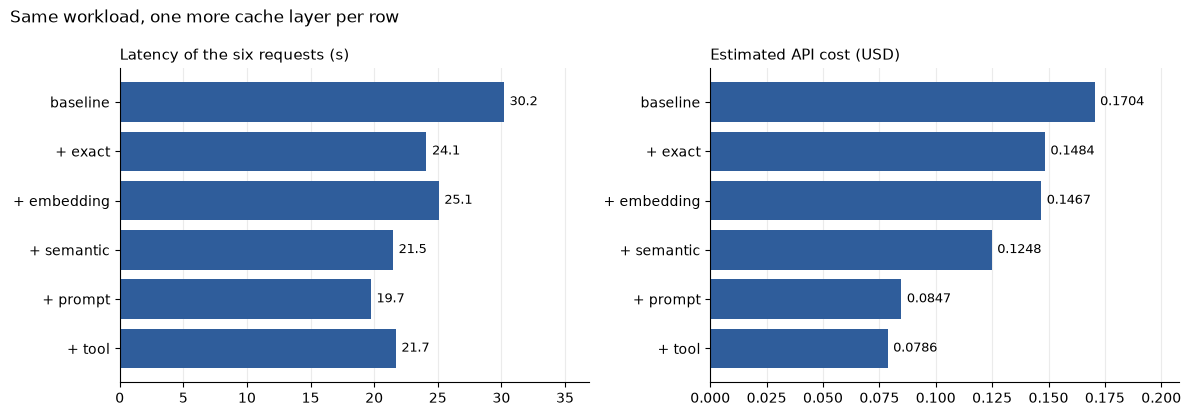

In [53]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.2))
panels = [("seconds", "Latency of the six requests (s)", "%.1f")]
panels += [("estimated_usd", "Estimated API cost (USD)", "%.4f")]
for axis, (column, title, fmt) in zip(axes, panels):
    bars = axis.barh(stage_frame["stage"], stage_frame[column], color="#2F5D9B")
    axis.bar_label(bars, fmt=fmt, padding=4, fontsize=9)
    axis.invert_yaxis()
    axis.set_title(title, loc="left", fontsize=11)
    axis.margins(x=0.22)
    axis.grid(axis="x", alpha=0.25)
    axis.set_axisbelow(True)
    axis.spines[["top", "right"]].set_visible(False)
figure.suptitle("Same workload, one more cache layer per row", x=0.01, ha="left")
figure.tight_layout()
plt.show()

## 6.3 · How to read these numbers

- **Answer layers dominate latency.** Each exact or semantic hit removes a whole model call, which is
  seconds of latency and most of a request's cost. Those layers move the latency panel most.
- **The prompt cache dominates cost on the remaining calls.** The stable prefix is most of every call's input;
  reading it from cache is priced at a small fraction of fresh input. The first call of a configuration pays a
  slightly higher price to write the prefix; every later call within five minutes reads it.
- **The embedding cache saves encoder work, not money here.** The encoder is local, so a hit saves
  milliseconds of CPU. With a hosted embedding API each avoided run would also avoid a metered request.
- **The tool cache saves one search and its credit.** The model still answers the live question; the evidence
  is the same, with its original collection time.
- **Latency is noisy.** Model and network latency vary from call to call by more than some layers save. Six
  requests show the direction of each effect; repeat the run several times, with your own traffic, before
  quoting a number.

## 6.4 · Production notes

- **Order the layers by cost and blast radius.** Exact before semantic (cheaper, no false recall), answer
  layers before evidence layers, and evidence layers before the model.
- **Route by request kind in the host.** Decide which requests may reuse answers from the endpoint or tool
  that produced them, never from the model's opinion of its own answer.
- **Invalidate with the source.** When the knowledge base changes (an issue is reopened, a fix is reverted),
  rotate the namespace of the answer caches or delete the affected entries on the primary; True Cache follows
  the primary without extra code.
- **Size the True Cache tier for the read path.** The exact cache's reads go to True Cache; keep a primary
  fallback for the moment right after a write, and monitor how often it is used.
- **Watch the semantic layer for false recall.** Log the matched question, distance and reranker score of
  every semantic hit, sample them for review, and tune the threshold per domain.
- **Keep the prompt prefix byte-stable.** Version it, keep timestamps and per-user data after the breakpoint,
  and alert when `cache_read_input_tokens` drops to zero.
- **Observe every layer.** Record which layer served each request (as `served_by` does here), plus hit rates,
  latency and cost per layer, so a regression in one layer is visible.

## 6.5 · Clean up

Remove what this run wrote: the exact-cache rows on the primary (including the probe) and the semantic-cache
rows of this run's namespaces (`OracleSemanticCache` stores the SHA-256 of the namespace in its metadata). The
tables and the knowledge base stay: the knowledge base is the agent's long-term memory, and loading it is
idempotent. Then close every connection.

In [54]:
with tc_primary.cursor() as cursor:
    cursor.execute(
        "DELETE FROM US_RESPONSE_CACHE WHERE namespace LIKE :run || '%'", run=RUN_ID
    )
    print("Exact-cache rows deleted on the primary:", cursor.rowcount)
tc_primary.commit()
hashes = [(hashlib.sha256(n.encode()).hexdigest(),) for n in NAMESPACES]
with conn.cursor() as cursor:
    sql = "DELETE FROM US_SEMANTIC_CACHE WHERE JSON_VALUE(metadata, '$.llm_string_hash') = :1"
    cursor.executemany(sql, hashes)
    print("Semantic-cache rows deleted:", cursor.rowcount)
conn.commit()

Exact-cache rows deleted on the primary: 13
Semantic-cache rows deleted: 6


Close the three database connections and the Anthropic client.

In [55]:
for connection in (tc_reader, tc_primary, conn):
    connection.close()
claude.close()
print("Connections closed.")

Connections closed.


### Takeaways

- Measure a stack one layer at a time on a frozen workload; each layer shows up in its own column.
- Answer layers save the most per hit and carry the most risk; evidence layers save less and are safer.
- Oracle True Cache gives the exact cache a read tier with no invalidation code: write to the primary, read
  through True Cache, fall back to the primary right after a write.
- Report signed savings, setup cost and unknown costs; a short run shows direction, not a benchmark.